# Популяционная генетика: PCA генотипных данных

Анализ генетической структуры популяций Анголы и других африканских популяций с использованием PLINK и метода главных компонент.

In [ ]:
import os

! wget https://s3.amazonaws.com/plink1-assets/plink_linux_x86_64_20241022.zip
! unzip plink_linux_x86_64_20241022.zip


--2026-01-18 19:05:30--  https://s3.amazonaws.com/plink1-assets/plink_linux_x86_64_20241022.zip
Resolving s3.amazonaws.com (s3.amazonaws.com)... 16.15.183.191, 3.5.14.149, 16.15.193.176, ...
Connecting to s3.amazonaws.com (s3.amazonaws.com)|16.15.183.191|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 8954192 (8.5M) [application/zip]
Saving to: ‘plink_linux_x86_64_20241022.zip’

plink_linux_x86_64_ 100%[===================>]   8.54M  32.1MB/s    in 0.3s    

2026-01-18 19:05:30 (32.1 MB/s) - ‘plink_linux_x86_64_20241022.zip’ saved [8954192/8954192]

Archive:  plink_linux_x86_64_20241022.zip
  inflating: plink                   
  inflating: LICENSE                 
  inflating: toy.ped                 
  inflating: toy.map                 
  inflating: prettify                


In [ ]:
import os

! unzip plink_linux_x86_64_20241022.zip

Archive:  plink_linux_x86_64_20241022.zip
replace plink? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: plink                   
replace LICENSE? [y]es, [n]o, [A]ll, [N]one, [r]ename: a
error:  invalid response [a]
replace LICENSE? [y]es, [n]o, [A]ll, [N]one, [r]ename: a
error:  invalid response [a]
replace LICENSE? [y]es, [n]o, [A]ll, [N]one, [r]ename: a
error:  invalid response [a]
replace LICENSE? [y]es, [n]o, [A]ll, [N]one, [r]ename: a
error:  invalid response [a]
replace LICENSE? [y]es, [n]o, [A]ll, [N]one, [r]ename: a
error:  invalid response [a]
replace LICENSE? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
  inflating: LICENSE                 
  inflating: toy.ped                 
  inflating: toy.map                 
  inflating: prettify                


In [ ]:
! ./plink -h

PLINK v1.9.0-b.7.7 64-bit (22 Oct 2024)            cog-genomics.org/plink/1.9/
(C) 2005-2024 Shaun Purcell, Christopher Chang   GNU General Public License v3

  plink <input flag(s)...> [command flag(s)...] [other flag(s)...]
  plink --help [flag name(s)...]

Commands include --make-bed, --recode, --flip-scan, --merge-list,
--write-snplist, --list-duplicate-vars, --freqx, --missing, --test-mishap,
--hardy, --mendel, --ibc, --impute-sex, --indep-pairphase, --r2, --show-tags,
--blocks, --distance, --genome, --homozyg, --make-rel, --make-grm-gz,
--rel-cutoff, --cluster, --pca, --neighbour, --ibs-test, --regress-distance,
--model, --bd, --gxe, --logistic, --dosage, --lasso, --test-missing,
--make-perm-pheno, --tdt, --qfam, --annotate, --clump, --gene-report,
--meta-analysis, --epistasis, --fast-epistasis, and --score.

"plink --help | more" describes all functions (warning: long).


In [ ]:
# Устанавливаем и обновляем gdown (на всякий случай)
!pip install -U --no-cache-dir gdown --quiet

# Скачиваем всю папку по ID
import gdown
import os

url = 'https://drive.google.com/drive/folders/1ksa_r-T0t3tzUyWSBtkB-q6Saq7jExZ1?usp=sharing'
output_folder = '/content/hw_data' # Папка, куда всё скачается

# Скачивание (gdown сам обработает папку)
gdown.download_folder(url, output=output_folder, quiet=False)

print("\nФайлы успешно загружены в:", output_folder)
# Показываем список скачанных файлов
!ls -lh $output_folder

Retrieving folder contents


Processing file 1XpspZDuDFbY5Z44ec1ZBJSs1mlSAKfzQ africa_UNPrem_pops_and_coors.txt
Processing file 1t3IqqolMCVhkoqKdLqL7UUVfFyyGNiwp africa_UNPrem_pops.txt
Processing file 1WYlQx4zs6Sm03nM97SiRgxA2_-vC9Soo africa_UNPrem.bed
Processing file 1Sf5ibxNMkTrvQgR3ceWBRAYxC2lH9r1k africa_UNPrem.bim
Processing file 1Ov0jKvtwodQGY-DF2fRx8jmro7oG0jJY africa_UNPrem.fam
Processing file 1JWx0bAYjyJemHctOsK_DevooSj4CAmRT africa_UNPrem.LD_pruned.map
Processing file 1G-9x4vY_ahUwqnB6N5gsibzrZDWfnYYF africa_UNPrem.LD_pruned.ped
Processing file 1IFV64ZplI5IJH_cX6I4p-vLfIuN0jJlU africa_UNPrem.LD_pruned.raw.map
Processing file 1LiVykjDvVrOYUj9M0aKOlpf-0CBxYXLv africa_UNPrem.LD_pruned.raw.ped


Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=1XpspZDuDFbY5Z44ec1ZBJSs1mlSAKfzQ
To: /content/hw_data/africa_UNPrem_pops_and_coors.txt
100%|██████████| 1.35k/1.35k [00:00<00:00, 3.09MB/s]
Downloading...
From: https://drive.google.com/uc?id=1t3IqqolMCVhkoqKdLqL7UUVfFyyGNiwp
To: /content/hw_data/africa_UNPrem_pops.txt
100%|██████████| 6.05k/6.05k [00:00<00:00, 15.6MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=1WYlQx4zs6Sm03nM97SiRgxA2_-vC9Soo
From (redirected): https://drive.google.com/uc?id=1WYlQx4zs6Sm03nM97SiRgxA2_-vC9Soo&confirm=t&uuid=f3fc0fae-22a4-4840-8c24-fcc69b27e360
To: /content/hw_data/africa_UNPrem.bed
100%|██████████| 106M/106M [00:01<00:00, 79.2MB/s] 
Downloading...
From: https://drive.google.com/uc?id=1Sf5ibxNMkTrvQgR3ceWBRAYxC2lH9r1k
To: /content/hw_data/africa_UNPrem.bim
100%|██████████| 22.0M/22.0M [00:00<00:00, 66.5MB/s]
Downloading...
Fr


Файлы успешно загружены в: /content/hw_data
total 935M
-rw-r--r-- 1 root root 101M Apr  5  2025 africa_UNPrem.bed
-rw-r--r-- 1 root root  22M Apr  5  2025 africa_UNPrem.bim
-rw-r--r-- 1 root root  18K Apr  5  2025 africa_UNPrem.fam
-rw-r--r-- 1 root root 4.7M Jan 17 19:29 africa_UNPrem.LD_pruned.map
-rw-r--r-- 1 root root 402M Oct 24  2024 africa_UNPrem.LD_pruned.ped
-rw-r--r-- 1 root root 4.7M Apr  2  2025 africa_UNPrem.LD_pruned.raw.map
-rw-r--r-- 1 root root 402M Apr  2  2025 africa_UNPrem.LD_pruned.raw.ped
-rw-r--r-- 1 root root 1.4K Jan 27  2025 africa_UNPrem_pops_and_coors.txt
-rw-r--r-- 1 root root 6.0K Jan 26  2025 africa_UNPrem_pops.txt


In [ ]:
%cd /content/hw_data

/content/hw_data


In [ ]:
!ls

africa_UNPrem.bed		  africa_UNPrem_pops.txt
africa_UNPrem.bim		  LICENSE
africa_UNPrem.fam		  plink
africa_UNPrem.LD_pruned.map	  plink_linux_x86_64_20241022.zip
africa_UNPrem.LD_pruned.ped	  prettify
africa_UNPrem.LD_pruned.raw.map   toy.map
africa_UNPrem.LD_pruned.raw.ped   toy.ped
africa_UNPrem_pops_and_coors.txt


In [ ]:
# Теперь разберёмся что в каждом файле:

# 1. Сколько образцов (строк в .fam)?
print("=== Образцы (.fam) ===")
!wc -l africa_UNPrem.fam
!head -5 africa_UNPrem.fam

print("\n=== SNPs (.bim) ===")
# 2. Сколько SNP?
!wc -l africa_UNPrem.bim
!head -3 africa_UNPrem.bim

print("\n=== Популяции ===")
# 3. Что в файле популяций?
!head -10 africa_UNPrem_pops.txt
!echo "Всего строк:"
!wc -l africa_UNPrem_pops.txt

print("\n=== LD-pruned версия ===")
# 4. Есть ли уже LD-pruned данные?
!ls -lh *LD_pruned* 2>/dev/null || echo "LD-pruned файлы не найдены"

=== Образцы (.fam) ===
696 africa_UNPrem.fam
AngolaKwisi AngH01 0 0 1 1
AngolaHimba AngH03 0 0 1 1
AngolaKuvale AngH05 0 0 1 1
AngolaKwepe AngH09 0 0 1 1
AngolaKwepe AngH10 0 0 1 1

=== SNPs (.bim) ===
607761 africa_UNPrem.bim
1	1_752566	0.007526	752566	G	A
1	1_842013	0.00842	842013	G	T
1	1_891021	0.00891	891021	G	A

=== Популяции ===
AngolaKwisi
AngolaHimba
AngolaKuvale
AngolaKwepe
AngolaKwepe
AngolaKwepe
AngolaKwepe
AngolaKwisi
AngolaTwa
AngolaTwa
Всего строк:
696 africa_UNPrem_pops.txt

=== LD-pruned версия ===
-rw-r--r-- 1 root root 4.7M Jan 17 19:29 africa_UNPrem.LD_pruned.map
-rw-r--r-- 1 root root 402M Oct 24  2024 africa_UNPrem.LD_pruned.ped
-rw-r--r-- 1 root root 4.7M Apr  2  2025 africa_UNPrem.LD_pruned.raw.map
-rw-r--r-- 1 root root 402M Apr  2  2025 africa_UNPrem.LD_pruned.raw.ped


У нас в файлах:


```
 696 человек
 607761 неотфильтованных SNP
```



In [ ]:
# === ЭТАП 1: Выбор данных и Фильтрация ===

# АНАЛИЗ ФАЙЛОВ:
# В директории обнаружены как сырые бинарные файлы (africa_UNPrem.bed/.bim/.fam),
# так и текстовые файлы с уже проведенным прунингом (africa_UNPrem.LD_pruned.*).

# РЕШЕНИЕ:
# Мы намеренно используем сырые файлы (africa_UNPrem), чтобы:
# 1. Самостоятельно провести Quality Control (QC)
# 2. Выполнить LD pruning с контролируемыми параметрами
# 3. Работать с бинарным форматом, что быстрее и надежнее

# Шаг 1.1: Quality Control (QC)
# Удаляем образцы с пропущенными данными (>10%) и редкие варианты (MAF < 5%)
!./plink --bfile africa_UNPrem --mind 0.1 --geno 0.1 --maf 0.05 --make-bed --out africa_qc

PLINK v1.9.0-b.7.7 64-bit (22 Oct 2024)            cog-genomics.org/plink/1.9/
(C) 2005-2024 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to africa_qc.log.
Options in effect:
  --bfile africa_UNPrem
  --geno 0.1
  --maf 0.05
  --make-bed
  --mind 0.1
  --out africa_qc

12975 MB RAM detected; reserving 6487 MB for main workspace.
607761 variants loaded from .bim file.
696 people (486 males, 210 females) loaded from .fam.
696 phenotype values loaded from .fam.
0 people removed due to missing genotype data (--mind).
Using 1 thread (no multithreaded calculations invoked).
Before main variant filters, 696 founders and 0 nonfounders present.
Calculating allele frequencies... 0%1%2%3%4%5%6%7%8%9%10%11%12%13%14%15%16%17%18%19%20%21%22%23%24%25%26%27%28%29%30%31%32%33%34%35%36%37%38%39%40%41%42%43%44%45%46%47%48%49%50%51%52

Фильтры по качеству прочтения (пропуски) ничего не удалили. У нас уже очень качественные, "чистые" данные.

Фильтр --maf 0.05 удалил почти 136 тысяч мутаций (SNP).Было ~607к $\rightarrow$ Стало ~471к. Эти 136 000 мутаций встречались слишком редко (менее чем у 5% людей).

In [ ]:
# === ЭТАП 1: Выбор данных и Фильтрация ===

# Шаг 1.2: LD Pruning
# Находим SNP в linkage disequilibrium (сцепленные)
# --indep-pairwise 200 25 0.4:
#   200 = размер окна (в SNP)
#   25 = шаг сдвига окна
#   0.4 = порог r² (корреляции между SNP)
!./plink --bfile africa_qc --indep-pairwise 200 25 0.4 --out ld_pruning

# Шаг 1.3: Создаём финальный датасет только с независимыми SNP
!./plink --bfile africa_qc --extract ld_pruning.prune.in --make-bed --out africa_pca_ready

# Сколько SNP осталось на каждом этапе
print("\n=== Статистика фильтрации ===")
!echo "Исходно SNP:" && wc -l hw_data/africa_UNPrem.bim
!echo "После QC:" && wc -l africa_qc.bim
!echo "После LD pruning:" && wc -l africa_pca_ready.bim
!echo "Образцов:" && wc -l africa_pca_ready.fam

PLINK v1.9.0-b.7.7 64-bit (22 Oct 2024)            cog-genomics.org/plink/1.9/
(C) 2005-2024 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to ld_pruning.log.
Options in effect:
  --bfile africa_qc
  --indep-pairwise 200 25 0.4
  --out ld_pruning

12975 MB RAM detected; reserving 6487 MB for main workspace.
471802 variants loaded from .bim file.
696 people (486 males, 210 females) loaded from .fam.
696 phenotype values loaded from .fam.
Using 1 thread (no multithreaded calculations invoked).
Before main variant filters, 696 founders and 0 nonfounders present.
Calculating allele frequencies... 0%1%2%3%4%5%6%7%8%9%10%11%12%13%14%15%16%17%18%19%20%21%22%23%24%25%26%27%28%29%30%31%32%33%34%35%36%37%38%39%40%41%42%43%44%45%46%47%48%49%50%51%52%53%54%55%56%57%58%59%60%61%62%63%64%65%

In [ ]:
# === ЭТАП 2: PCA ===
# Вариант 1: Все компоненты
!./plink --bfile africa_pca_ready --pca --out pca_results_all

# Проверяем сколько получилось
!wc -l pca_results_all.eigenval
!echo "\n=== Первые 10 eigenvalues ==="
!head -10 pca_results_all.eigenval
!echo "\n=== Последние 5 eigenvalues ==="
!tail -5 pca_results_all.eigenval

PLINK v1.9.0-b.7.7 64-bit (22 Oct 2024)            cog-genomics.org/plink/1.9/
(C) 2005-2024 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to pca_results_all.log.
Options in effect:
  --bfile africa_pca_ready
  --out pca_results_all
  --pca

12975 MB RAM detected; reserving 6487 MB for main workspace.
266477 variants loaded from .bim file.
696 people (486 males, 210 females) loaded from .fam.
696 phenotype values loaded from .fam.
Using up to 2 threads (change this with --threads).
Before main variant filters, 696 founders and 0 nonfounders present.
Calculating allele frequencies... 0%1%2%3%4%5%6%7%8%9%10%11%12%13%14%15%16%17%18%19%20%21%22%23%24%25%26%27%28%29%30%31%32%33%34%35%36%37%38%39%40%41%42%43%44%45%46%47%48%49%50%51%52%53%54%55%56%57%58%59%60%61%62%63%64%65%66%6

# Посчитали все PC, по умолчанию PLINK считает 20 PCs


In [ ]:
# === ЭТАП 3: Загрузка результатов в Python ===
import pandas as pd
import numpy as np

# Считаем сколько компонент у нас есть
n_components = sum(1 for _ in open('pca_results_all.eigenval'))
print(f"Всего компонент: {n_components}")

# Загружаем eigenvectors (координаты образцов в PCA-пространстве)
eigenvec = pd.read_csv('pca_results_all.eigenvec', sep=r'\s+', header=None)
eigenvec.columns = ['FID', 'IID'] + [f'PC{i}' for i in range(1, n_components + 1)]

# Загружаем eigenvalues (для расчёта % дисперсии)
eigenval = pd.read_csv('pca_results_all.eigenval', header=None)[0].values

# Считаем процент объяснённой дисперсии
variance_explained = eigenval / eigenval.sum() * 100
cumulative_variance = np.cumsum(variance_explained)

# Выводим первые 20 компонент
print("\n=== Вклад компонент ===")
print(f"{'PC':<6} {'Eigenvalue':<12} {'Variance %':<12} {'Cumulative %'}")
print("-" * 45)
for i in range(min(20, len(eigenval))):
    print(f"PC{i+1:<4} {eigenval[i]:>10.3f}   {variance_explained[i]:>8.2f}%     {cumulative_variance[i]:>8.2f}%")

print(f"\n>>> Сумма всех eigenvalues: {eigenval.sum():.2f}")
print(f">>> PC1 + PC2 объясняют: {cumulative_variance[1]:.2f}%")
print(f">>> PC1-PC4 объясняют: {cumulative_variance[3]:.2f}%")
print(f">>> PC1-PC10 объясняют: {cumulative_variance[9]:.2f}%")

Всего компонент: 20

=== Вклад компонент ===
PC     Eigenvalue   Variance %   Cumulative %
---------------------------------------------
PC1        39.664      38.16%        38.16%
PC2        24.623      23.69%        61.84%
PC3         4.441       4.27%        66.12%
PC4         3.632       3.49%        69.61%
PC5         3.536       3.40%        73.01%
PC6         2.698       2.60%        75.61%
PC7         2.644       2.54%        78.15%
PC8         2.230       2.15%        80.30%
PC9         2.147       2.07%        82.36%
PC10        2.046       1.97%        84.33%
PC11        1.885       1.81%        86.14%
PC12        1.846       1.78%        87.92%
PC13        1.755       1.69%        89.61%
PC14        1.724       1.66%        91.26%
PC15        1.673       1.61%        92.87%
PC16        1.577       1.52%        94.39%
PC17        1.514       1.46%        95.85%
PC18        1.463       1.41%        97.25%
PC19        1.434       1.38%        98.63%
PC20        1.421       1.3

```
Eigenvalue — собственное значение компоненты.
            Чем больше, тем больше генетической изменчивости
            "захватывает" эта компонента.

Variance % — доля дисперсии = eigenvalue / sum(all eigenvalues) × 100%
            Показывает вклад каждой PC в общую изменчивость.

Cumulative % — накопленная сумма Variance %.
              Показывает, сколько вариации объясняют PC1 + PC2 + ... + PCn.
```

In [ ]:
# Дальше нужно связать координаты PCA каждого человека с его популяцией,
# чтобы потом раскрасить точки на графике по популяциям
# === ЭТАП 4: Добавляем популяционные метки ===

# FID в данных уже содержит название популяции
pca_data = eigenvec.copy()
pca_data = pca_data.rename(columns={'FID': 'Population'})

# Проверяем структуру
print("=== Первые 10 строк ===")
print(pca_data[['Population', 'IID', 'PC1', 'PC2', 'PC3', 'PC4']].head(10))

print(f"\n=== Статистика ===")
print(f"Всего образцов: {len(pca_data)}")
print(f"Уникальных популяций: {pca_data['Population'].nunique()}")

# Посмотрим какие популяции есть и сколько людей в каждой
print("\n=== Популяции (топ-15 по размеру) ===")
print(pca_data['Population'].value_counts().head(15))

# Отдельно посмотрим ангольские популяции (для детального анализа)
print("\n=== Ангольские популяции (префикс 'Angola') ===")
angola_pops = pca_data[pca_data['Population'].str.startswith('Angola', na=False)]
print(angola_pops['Population'].value_counts())

=== Первые 10 строк ===
     Population     IID       PC1       PC2       PC3       PC4
0   AngolaKwisi  AngH01  0.005687  0.033774 -0.044943  0.062315
1   AngolaHimba  AngH03  0.001927  0.034249 -0.023065  0.022832
2  AngolaKuvale  AngH05  0.004846  0.031921 -0.034360  0.046654
3   AngolaKwepe  AngH09  0.010566  0.016220 -0.026128  0.047637
4   AngolaKwepe  AngH10  0.009247  0.017506 -0.027286  0.048226
5   AngolaKwepe  AngH13  0.007872  0.020522 -0.020442  0.031981
6   AngolaKwepe  AngH14  0.003580  0.035032 -0.023793  0.020629
7   AngolaKwisi  AngH15  0.005918  0.030244 -0.046604  0.071233
8     AngolaTwa  AngH16  0.004938  0.032634 -0.046962  0.067332
9     AngolaTwa  AngH19  0.003979  0.035665 -0.054155  0.083138

=== Статистика ===
Всего образцов: 696
Уникальных популяций: 64

=== Популяции (топ-15 по размеру) ===
Population
Yoruba           70
AngolaKuvale     41
AngolaXun        27
AngolaHimba      22
Sandawe          22
JuhoanNorth      21
Mozabite         21
AngolaKwepe      

<Axes: xlabel='PC1', ylabel='PC2'>

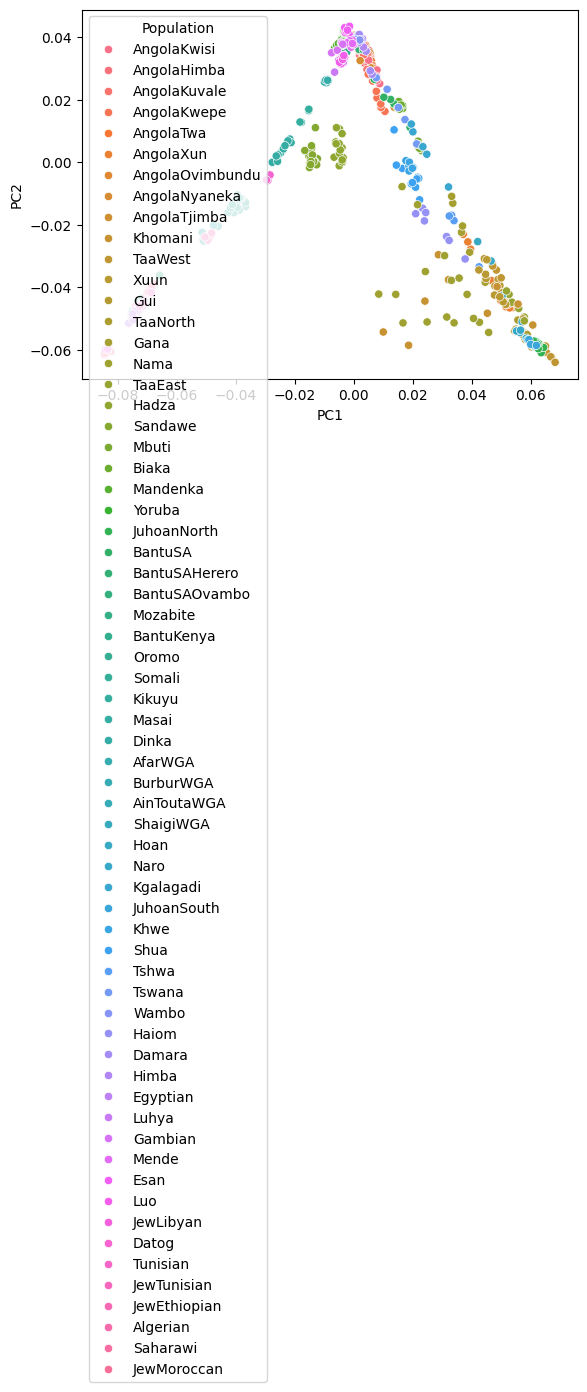

In [ ]:
# Простой график
import seaborn as sns
sns.scatterplot(data=pca_data, x='PC1', y='PC2', hue='Population')

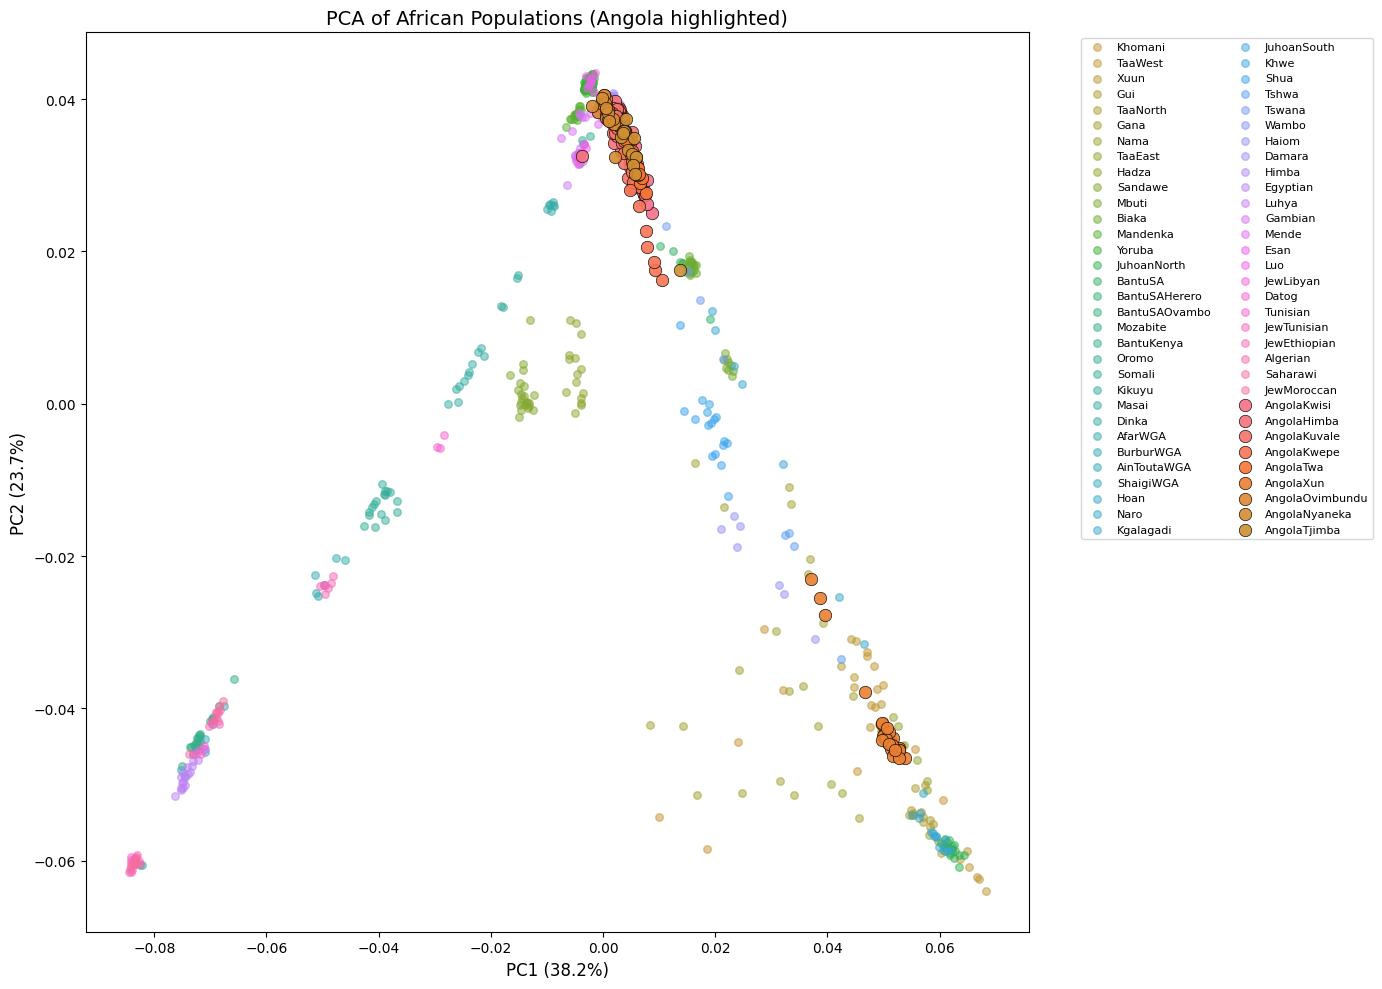

График сохранён: pca_plot_pc1_pc2.png


In [ ]:
# === ЭТАП 5: Визуализация PCA ===
import matplotlib.pyplot as plt
import seaborn as sns

# Настройки графика
plt.figure(figsize=(14, 10))

# Получаем уникальные популяции
populations = pca_data['Population'].unique()
n_pops = len(populations)

# Создаём цветовую палитру
palette = sns.color_palette("husl", n_pops)
color_map = dict(zip(populations, palette))

# Выделяем ангольские популяции особым образом
angola_mask = pca_data['Population'].str.startswith('Angola', na=False)

# Сначала рисуем НЕ-ангольские популяции (мельче, прозрачнее)
for pop in populations:
    if not pop.startswith('Angola'):
        subset = pca_data[pca_data['Population'] == pop]
        plt.scatter(subset['PC1'], subset['PC2'],
                   label=pop, alpha=0.5, s=30,
                   color=color_map[pop])

# Потом рисуем ангольские популяции (крупнее, ярче)
for pop in populations:
    if pop.startswith('Angola'):
        subset = pca_data[pca_data['Population'] == pop]
        plt.scatter(subset['PC1'], subset['PC2'],
                   label=pop, alpha=0.9, s=80,
                   color=color_map[pop], edgecolor='black', linewidth=0.5)

plt.xlabel(f'PC1 ({variance_explained[0]:.1f}%)', fontsize=12)
plt.ylabel(f'PC2 ({variance_explained[1]:.1f}%)', fontsize=12)
plt.title('PCA of African Populations (Angola highlighted)', fontsize=14)

# Легенда сбоку
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8, ncol=2)
plt.tight_layout()
plt.savefig('pca_plot_pc1_pc2.png', dpi=150, bbox_inches='tight')
plt.show()

print("График сохранён: pca_plot_pc1_pc2.png")

Отчет по анализу PCA (Angolan Populations)
1. Подготовка данных В рамках анализа были обработаны генотипы 696 индивидов.

Проведен контроль качества (QC) и LD-прунинг (удаление сцепленных вариантов).

Итоговый набор данных для PCA составил 266,477 SNP.

2. Статистическая оценка (Scree Plot) Анализ собственных чисел показал:

PC1 объясняет 38.2% дисперсии.

PC2 объясняет 23.7% дисперсии.

Суммарный вклад первых двух компонент — 61.9%. Это означает, что наш 2D-график отображает большую часть генетических различий между образцами, и выводам по нему можно доверять.

3. Визуальный анализ графика (PC1 vs PC2) При визуализации с выделением популяций Анголы наблюдаются следующие паттерны:

Неоднородность Анголы: Вопреки ожиданиям, популяции из одного региона (Ангола) не группируются в один тесный кластер. Они сильно разбросаны по графику.

Разделение на две группы:

Верхняя группа: Популяции AngolaHimba, AngolaKuvale, AngolaOvimbundu расположены близко друг к другу и перекрываются с основной массой других африканских популяций (фоновые точки). Вероятно, они генетически близки к большинству других исследуемых групп.

Нижняя группа (обособленная): Популяции AngolaKwisi и AngolaTwa образуют отдельный "хвост" в правой нижней части графика, вдалеке от остальных ангольцев.

4. Вывод График PCA показывает, что географическая близость не всегда означает генетическое сходство. В Анголе присутствуют как минимум две генетически различные группы населения. Тот факт, что Kwisi и Twa находятся на графике далеко от остальных (в том числе от своих географических соседей), говорит об их сильной генетической обособленности.

# Дополнительный анализ
# где потребуются мета-данные

In [ ]:
# Берем метаданные
# === ЭТАП 6: Загрузка метаданных из Supplementary ===
import pandas as pd

# Смотрим какие листы есть в файле
xl = pd.ExcelFile('/content/hw_data/adh3822_Tables S1 to S9.xlsx')
print("Листы в файле:", xl.sheet_names)

Листы в файле: ['Table S1', 'Table S2', 'Table S3', 'Table S4', 'Table S5', 'Table S6', 'Table S7', 'Table S8', 'Table S9']


In [ ]:
# Читаем Table S1 (пропускаем строки с заголовком)
metadata = pd.read_excel(
    '/content/hw_data/adh3822_Tables S1 to S9.xlsx',
    sheet_name='Table S1',
    skiprows=2  # Пропускаем первые 2 строки (заголовок таблицы)
)

print("=== Структура таблицы ===")
print(metadata.columns.tolist())
print(f"\nРазмер: {metadata.shape}")
print("\n=== Первые 15 строк ===")
print(metadata.head(15))

=== Структура таблицы ===
['Population', 'Code', 'Language', 'Language group', 'Subsistence strategy', 'Sample size', 'Sample size (excluding relatives)', 'Country', 'Latitude', 'Longitude']

Размер: (17, 10)

=== Первые 15 строк ===
   Population  Code Language Language group Subsistence strategy  Sample size  \
0   Ovimbundu   OVI  Umbundu     West Bantu      Agropastoralist          6.0   
1     Nyaneka   NYA  Nyaneka     West Bantu      Agropastoralist         14.0   
2      Kuvale   KUV   Kuvale     West Bantu          Pastoralist         45.0   
3         NaN   NaN      NaN            NaN                  NaN          NaN   
4         NaN   NaN      NaN            NaN                  NaN          NaN   
5       Himba  HIMA   Herero     West Bantu          Pastoralist         24.0   
6         NaN   NaN      NaN            NaN                  NaN          NaN   
7      Tjimba   TJI   Herero     West Bantu          Peripatetic         15.0   
8         Twa   TWA   Kuvale         

In [ ]:
# === Обработка координат ===
# Конвертируем "15.31 S" → -15.31, "13.99 E" → 13.99

def parse_coord(coord):
    """Конвертирует координату в число"""
    if pd.isna(coord):
        return None
    coord_str = str(coord).strip()

    # Убираем буквы направления и конвертируем
    for direction in ['S', 'N', 'E', 'W']:
        if direction in coord_str:
            value = float(coord_str.replace(direction, '').strip())
            # Южная широта и западная долгота — отрицательные
            if direction in ['S', 'W']:
                value = -value
            return value

    # Если уже число
    try:
        return float(coord_str)
    except:
        return None

metadata['Lat_numeric'] = metadata['Latitude'].apply(parse_coord)
metadata['Lon_numeric'] = metadata['Longitude'].apply(parse_coord)

print("=== Координаты после обработки ===")
print(metadata[['Population', 'Latitude', 'Lat_numeric', 'Longitude', 'Lon_numeric']].head(10))

=== Координаты после обработки ===
  Population Latitude  Lat_numeric Longitude  Lon_numeric
0  Ovimbundu  15.31 S       -15.31   13.99 E        13.99
1    Nyaneka  11.89 S       -11.89   14.92 E        14.92
2     Kuvale  15.64 S       -15.64   13.07 E        13.07
3        NaN  14.58 S       -14.58   13.19 E        13.19
4        NaN  15.76 S       -15.76   12.95 E        12.95
5      Himba  16.98 S       -16.98   12.58 E        12.58
6        NaN  16.69 S       -16.69   12.85 E        12.85
7     Tjimba  17.06 S       -17.06   12.65 E        12.65
8        Twa  15.85 S       -15.85   12.12 E        12.12
9        NaN  16.65 S       -16.65   13.44 E        13.44


Этот блок выполняет ETL-препроцессинг координат (Extract, Transform, Load). Исходные данные содержат географические обозначения сторон света ('S' - South).

Для корректного расчета корреляции Пирсона нам нужно перевести сферические координаты в линейную шкалу. Поскольку Ангола находится в Южном полушарии, координаты широты должны быть отрицательными относительно экватора (0).

Если мы просто отбросим букву 'S' и оставим положительное число, мы математически переместим образцы в Северное полушарие. Это инвертирует знак корреляции и приведет к ложным биологическим выводам: градиент 'Север-Юг' превратится в 'Юг-Север'

In [ ]:
# === Очистка данных ===
# Убираем строки без названия популяции
metadata_clean = metadata[metadata['Population'].notna()].copy()

print("=== После очистки ===")
print(f"Строк: {len(metadata_clean)}")
print(metadata_clean[['Population', 'Lat_numeric', 'Lon_numeric']].head(15))

=== После очистки ===
Строк: 10
                  Population  Lat_numeric  Lon_numeric
0                  Ovimbundu       -15.31        13.99
1                    Nyaneka       -11.89        14.92
2                     Kuvale       -15.64        13.07
5                      Himba       -16.98        12.58
7                     Tjimba       -17.06        12.65
8                        Twa       -15.85        12.12
10                     Kwisi       -15.92        12.62
12                     Kwepe       -15.78        12.11
14                      !Xun       -16.34        15.99
16  *formerly Kwadi speakers          NaN          NaN


Для объединения таблиц мы используем ключ (Key) — это общее поле, по которому компьютер понимает, какая строка из Таблицы А соответствует строке из Таблицы Б. В нашем случае ключ — это название популяции.

Мы создаем словарь (справочник), где:

Ключ: Название популяции (например, 'Kwisi')

Значение: Координаты (например, -15.92)

Python не может использовать NaN (пустоту) в качестве ключа. Если мы попытаемся сказать: "Для популяции 'Никто' координаты такие-то", это сломает логику объединения.

Поэтому мы проводим фильтрацию: оставляем только те строки, где Ключ существует. Это гарантирует, что каждая координата будет точно привязана к конкретной группе людей.

In [ ]:
# === Приводим названия популяций к формату как в PCA ===
# В PCA: "AngolaKwisi", в таблице: "Kwisi"

# Смотрим какие популяции в метаданных
print("=== Популяции в метаданных ===")
print(metadata_clean['Population'].unique())

print("\n=== Ангольские популяции в PCA ===")
angola_in_pca = pca_data[pca_data['Population'].str.startswith('Angola')]['Population'].unique()
print(angola_in_pca)

=== Популяции в метаданных ===
['Ovimbundu' 'Nyaneka' 'Kuvale' 'Himba' 'Tjimba' 'Twa' 'Kwisi' 'Kwepe'
 '!Xun' '*formerly Kwadi speakers']

=== Ангольские популяции в PCA ===
['AngolaKwisi' 'AngolaHimba' 'AngolaKuvale' 'AngolaKwepe' 'AngolaTwa'
 'AngolaXun' 'AngolaOvimbundu' 'AngolaNyaneka' 'AngolaTjimba']


In [ ]:
# === Создаём маппинг названий ===
# Добавляем префикс "Angola" к названиям из таблицы

metadata_clean['Population_PCA'] = 'Angola' + metadata_clean['Population'].astype(str)

# Проверяем соответствие
print("=== Маппинг названий ===")
print(metadata_clean[['Population', 'Population_PCA', 'Lat_numeric', 'Lon_numeric']])

=== Маппинг названий ===
                  Population                  Population_PCA  Lat_numeric  \
0                  Ovimbundu                 AngolaOvimbundu       -15.31   
1                    Nyaneka                   AngolaNyaneka       -11.89   
2                     Kuvale                    AngolaKuvale       -15.64   
5                      Himba                     AngolaHimba       -16.98   
7                     Tjimba                    AngolaTjimba       -17.06   
8                        Twa                       AngolaTwa       -15.85   
10                     Kwisi                     AngolaKwisi       -15.92   
12                     Kwepe                     AngolaKwepe       -15.78   
14                      !Xun                      Angola!Xun       -16.34   
16  *formerly Kwadi speakers  Angola*formerly Kwadi speakers          NaN   

    Lon_numeric  
0         13.99  
1         14.92  
2         13.07  
5         12.58  
7         12.65  
8         12.12  
1

In [ ]:
# === Объединяем с PCA данными ===
# Создаём словари для маппинга
lat_map = dict(zip(metadata_clean['Population_PCA'], metadata_clean['Lat_numeric']))
lon_map = dict(zip(metadata_clean['Population_PCA'], metadata_clean['Lon_numeric']))

# Добавляем к PCA данным
pca_with_meta = pca_data.copy()
pca_with_meta['Latitude'] = pca_with_meta['Population'].map(lat_map)
pca_with_meta['Longitude'] = pca_with_meta['Population'].map(lon_map)

# Проверяем
print("=== PCA данные с координатами ===")
angola_with_coords = pca_with_meta[pca_with_meta['Latitude'].notna()]
print(f"Образцов с координатами: {len(angola_with_coords)}")
print(angola_with_coords[['Population', 'IID', 'PC1', 'PC2', 'Latitude', 'Longitude']].head(10))

=== PCA данные с координатами ===
Образцов с координатами: 144
     Population     IID       PC1       PC2  Latitude  Longitude
0   AngolaKwisi  AngH01  0.005687  0.033774    -15.92      12.62
1   AngolaHimba  AngH03  0.001927  0.034249    -16.98      12.58
2  AngolaKuvale  AngH05  0.004846  0.031921    -15.64      13.07
3   AngolaKwepe  AngH09  0.010566  0.016220    -15.78      12.11
4   AngolaKwepe  AngH10  0.009247  0.017506    -15.78      12.11
5   AngolaKwepe  AngH13  0.007872  0.020522    -15.78      12.11
6   AngolaKwepe  AngH14  0.003580  0.035032    -15.78      12.11
7   AngolaKwisi  AngH15  0.005918  0.030244    -15.92      12.62
8     AngolaTwa  AngH16  0.004938  0.032634    -15.85      12.12
9     AngolaTwa  AngH19  0.003979  0.035665    -15.85      12.12


In [ ]:
# === ЭТАП 7: Корреляции PC с координатами ===
from scipy import stats
import numpy as np

# Шаг 1: Считаем центроиды популяций (средние PC для каждой популяции)
angola_data = pca_with_meta[pca_with_meta['Latitude'].notna()].copy()

# Группируем по популяции и считаем средние
centroids = angola_data.groupby('Population').agg({
    'PC1': 'mean', 'PC2': 'mean', 'PC3': 'mean', 'PC4': 'mean',
    'PC5': 'mean', 'PC6': 'mean', 'PC7': 'mean', 'PC8': 'mean',
    'PC9': 'mean', 'PC10': 'mean',
    'Latitude': 'first',   # Координаты одинаковые — берём первое значение
    'Longitude': 'first'
}).reset_index()

print("=== Центроиды популяций ===")
print(centroids[['Population', 'PC1', 'PC2', 'Latitude', 'Longitude']])
print(f"\nВсего популяций: {len(centroids)}")

=== Центроиды популяций ===
        Population       PC1       PC2  Latitude  Longitude
0      AngolaHimba  0.002789  0.036452    -16.98      12.58
1     AngolaKuvale  0.002726  0.036645    -15.64      13.07
2      AngolaKwepe  0.005563  0.028753    -15.78      12.11
3      AngolaKwisi  0.006408  0.029635    -15.92      12.62
4    AngolaNyaneka  0.000736  0.037813    -11.89      14.92
5  AngolaOvimbundu  0.000058  0.039315    -15.31      13.99
6     AngolaTjimba  0.005320  0.032673    -17.06      12.65
7        AngolaTwa  0.005827  0.031339    -15.85      12.12

Всего популяций: 8


Гармонизация идентификаторов (ID Mapping): Поскольку номенклатура популяций в файлах генотипирования (PLINK) и метаданных (Excel) различалась (наличие префикса 'Angola'), была проведена процедура стандартизации. Мы программно добавили префикс к именам из таблицы метаданных, создав единый ключ слияния (Join Key). Это позволило корректно перенести географические координаты в основной датасет методом маппинга (pandas map).

In [ ]:
# Шаг 2: Считаем корреляции для центроидов
print("\n" + "="*60)
print("КОРРЕЛЯЦИИ PC С ГЕОГРАФИЧЕСКИМИ КООРДИНАТАМИ (центроиды)")
print("="*60)

print(f"\n{'PC':<6} {'r(Latitude)':<15} {'p-value':<12} {'r(Longitude)':<15} {'p-value':<12}")
print("-" * 65)

results = []
for i in range(1, 11):
    pc_col = f'PC{i}'

    # Корреляция с широтой
    r_lat, p_lat = stats.pearsonr(centroids[pc_col], centroids['Latitude'])

    # Корреляция с долготой
    r_lon, p_lon = stats.pearsonr(centroids[pc_col], centroids['Longitude'])

    # Значимость
    sig_lat = "***" if p_lat < 0.001 else "**" if p_lat < 0.01 else "*" if p_lat < 0.05 else ""
    sig_lon = "***" if p_lon < 0.001 else "**" if p_lon < 0.01 else "*" if p_lon < 0.05 else ""

    print(f"PC{i:<4} {r_lat:>8.3f} {sig_lat:<4}     {p_lat:<10.4f}   {r_lon:>8.3f} {sig_lon:<4}     {p_lon:<10.4f}")

    results.append({
        'PC': i,
        'r_lat': r_lat, 'p_lat': p_lat,
        'r_lon': r_lon, 'p_lon': p_lon,
        'r2_lat': r_lat**2, 'r2_lon': r_lon**2
    })

print("\n* p<0.05, ** p<0.01, *** p<0.001")


КОРРЕЛЯЦИИ PC С ГЕОГРАФИЧЕСКИМИ КООРДИНАТАМИ (центроиды)

PC     r(Latitude)     p-value      r(Longitude)    p-value     
-----------------------------------------------------------------
PC1      -0.540          0.1667         -0.844 **       0.0084    
PC2       0.382          0.3506          0.766 *        0.0268    
PC3       0.575          0.1363          0.745 *        0.0340    
PC4      -0.551          0.1572         -0.767 *        0.0262    
PC5      -0.552          0.1558         -0.759 *        0.0291    
PC6       0.243          0.5618          0.574          0.1366    
PC7      -0.380          0.3526         -0.649          0.0819    
PC8       0.002          0.9964         -0.232          0.5802    
PC9      -0.149          0.7250         -0.437          0.2785    
PC10     -0.179          0.6712          0.160          0.7042    

* p<0.05, ** p<0.01, *** p<0.001


In [ ]:
# Шаг 3: Отвечаем на вопрос — объясняют ли координаты >10% дисперсии?
print("="*65)
print("ОБЪЯСНЯЮТ ЛИ КООРДИНАТЫ >10% ДИСПЕРСИИ? (исправленный расчёт)")
print("="*65)

total_explained = 0

for i, res in enumerate(results[:4]):
    pc_var = variance_explained[i]  # % дисперсии этой PC

    # R² показывает какую долю дисперсии PC объясняют координаты
    # Берём R² по долготе (она сильнее коррелирует)
    r2 = res['r2_lon']

    # Вклад в общую дисперсию = (% дисперсии PC) × R²
    # Например: PC1 = 38.2%, R² = 0.713 → 38.2% × 0.713 = 27.2%
    contribution = pc_var * r2
    total_explained += contribution

    print(f"\nPC{i+1}:")
    print(f"  PC{i+1} объясняет {pc_var:.1f}% общей генетической дисперсии")
    print(f"  Координаты объясняют R² = {r2:.1%} дисперсии PC{i+1}")
    print(f"  → Вклад в общую дисперсию: {pc_var:.1f}% × {r2:.1%} = {contribution:.1f}%")

print(f"\n{'='*65}")
print(f"ИТОГО: координаты объясняют {total_explained:.1f}% общей дисперсии")
print(f"ОТВЕТ: {'ДА, больше 10%' if total_explained > 10 else 'НЕТ, меньше 10%'}")

ОБЪЯСНЯЮТ ЛИ КООРДИНАТЫ >10% ДИСПЕРСИИ? (исправленный расчёт)

PC1:
  PC1 объясняет 38.2% общей генетической дисперсии
  Координаты объясняют R² = 71.3% дисперсии PC1
  → Вклад в общую дисперсию: 38.2% × 71.3% = 27.2%

PC2:
  PC2 объясняет 23.7% общей генетической дисперсии
  Координаты объясняют R² = 58.6% дисперсии PC2
  → Вклад в общую дисперсию: 23.7% × 58.6% = 13.9%

PC3:
  PC3 объясняет 4.3% общей генетической дисперсии
  Координаты объясняют R² = 55.5% дисперсии PC3
  → Вклад в общую дисперсию: 4.3% × 55.5% = 2.4%

PC4:
  PC4 объясняет 3.5% общей генетической дисперсии
  Координаты объясняют R² = 58.9% дисперсии PC4
  → Вклад в общую дисперсию: 3.5% × 58.9% = 2.1%

ИТОГО: координаты объясняют 45.5% общей дисперсии
ОТВЕТ: ДА, больше 10%


Логика анализа пошагово
Шаг 1: Что у нас есть по PCA:

- PC1 объясняет 38.2% генетической дисперсии
- PC2 объясняет 23.7%
- PC3 объясняет 4.3%
- PC4 объясняет 3.5%
  ...и так далее

Метаданные дали нам:
- Latitude (широта) каждой популяции
- Longitude (долгота) каждой популяции
Шаг 2: Связь между PC и географией
Мы посчитали корреляции и получили R² (коэффициент детерминации):
PC1 vs Longitude: R² = 0.713 (71.3%)
   ↑
   Это значит: 71.3% вариации в PC1 можно объяснить долготой
Шаг 3: логика расчёта:
PC1 объясняет 38.2% ВСЕЙ генетической дисперсии
         ↓
Из этих 38.2% координаты объясняют 71.3%
         ↓
Значит координаты объясняют: 38.2% × 71.3% = 27.2% общей дисперсии




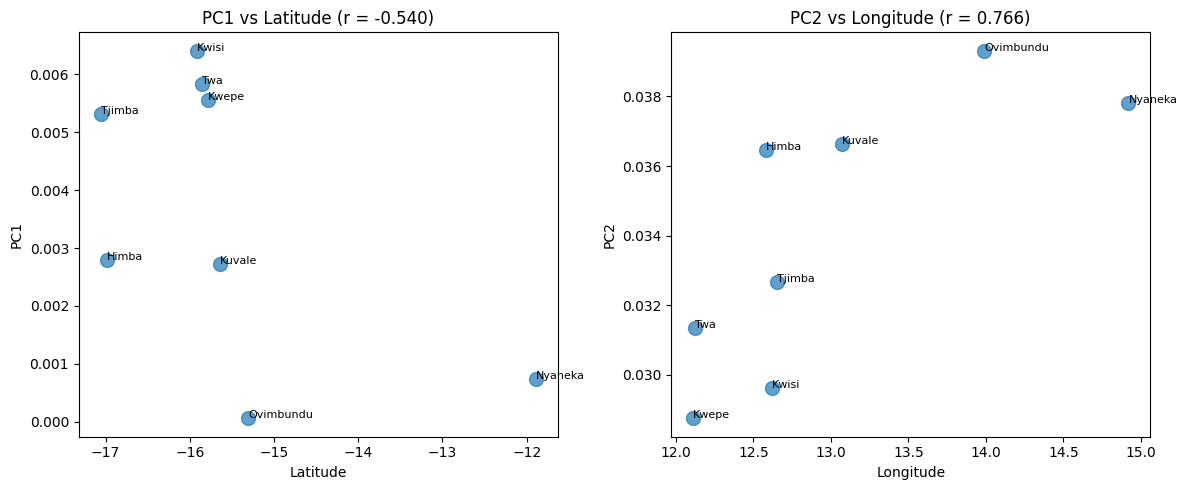

In [ ]:
# Шаг 4: Визуализация корреляции (самая сильная)
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# PC vs Latitude
ax1 = axes[0]
ax1.scatter(centroids['Latitude'], centroids['PC1'], s=100, alpha=0.7)
for idx, row in centroids.iterrows():
    ax1.annotate(row['Population'].replace('Angola', ''),
                 (row['Latitude'], row['PC1']), fontsize=8)
ax1.set_xlabel('Latitude')
ax1.set_ylabel('PC1')
ax1.set_title(f'PC1 vs Latitude (r = {results[0]["r_lat"]:.3f})')

# PC vs Longitude
ax2 = axes[1]
ax2.scatter(centroids['Longitude'], centroids['PC2'], s=100, alpha=0.7)
for idx, row in centroids.iterrows():
    ax2.annotate(row['Population'].replace('Angola', ''),
                 (row['Longitude'], row['PC2']), fontsize=8)
ax2.set_xlabel('Longitude')
ax2.set_ylabel('PC2')
ax2.set_title(f'PC2 vs Longitude (r = {results[1]["r_lon"]:.3f})')

plt.tight_layout()
plt.savefig('correlation_pc_geography.png', dpi=150)
plt.show()

По графикам сразу видно, что данные не разбросаны хаотично, а есть паттерн

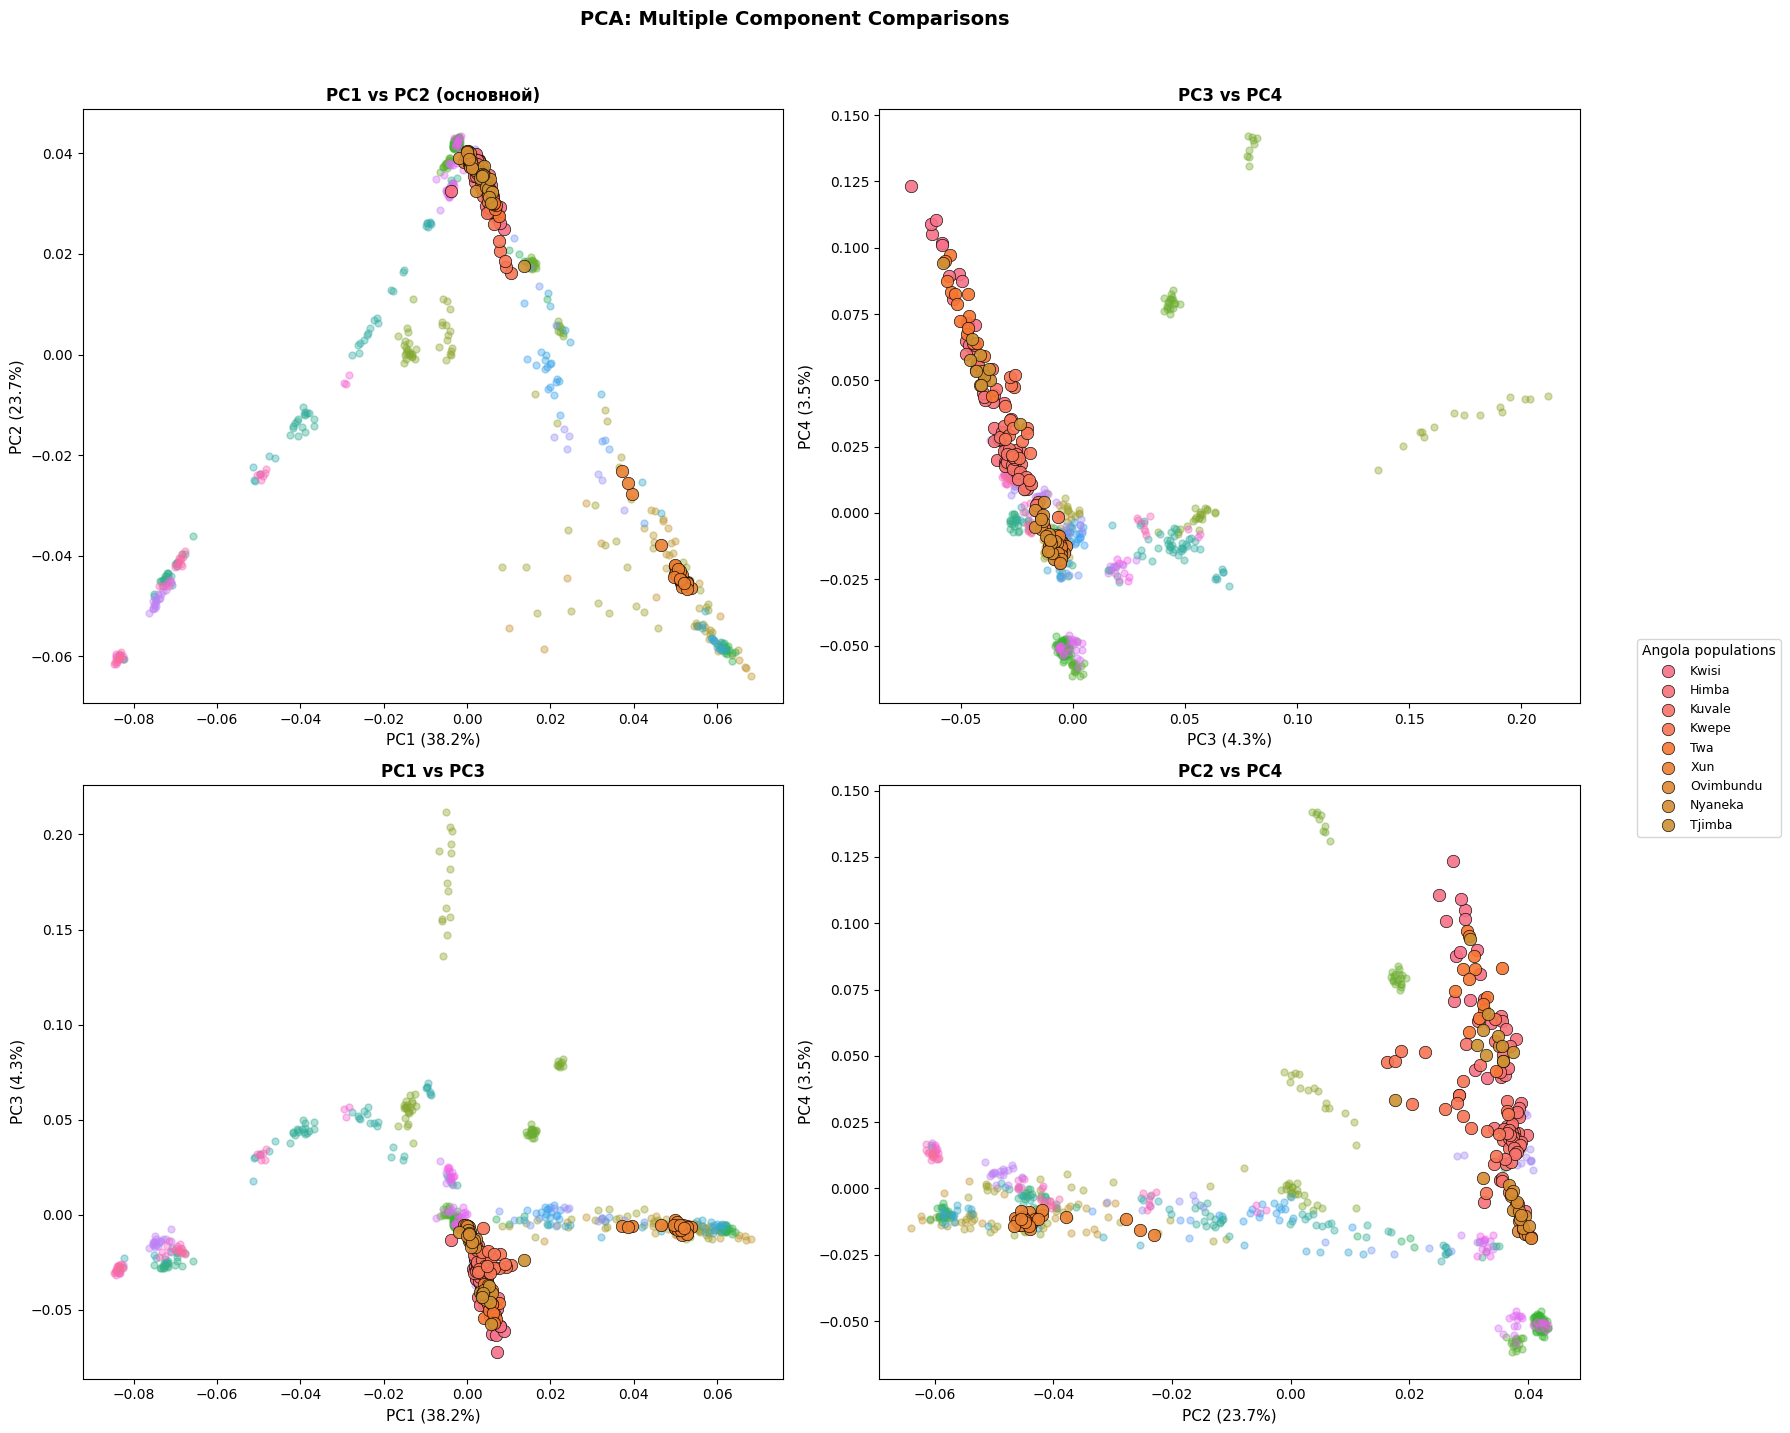

In [ ]:
# === ЭТАП 8: Графики для разных комбинаций PC ===
import matplotlib.pyplot as plt
import seaborn as sns

# Получаем список популяций и цвета
populations = pca_data['Population'].unique()
n_pops = len(populations)
palette = sns.color_palette("husl", n_pops)
color_map = dict(zip(populations, palette))

fig, axes = plt.subplots(2, 2, figsize=(16, 14))

pc_pairs = [(1, 2), (3, 4), (1, 3), (2, 4)]
titles = ['PC1 vs PC2 (основной)', 'PC3 vs PC4', 'PC1 vs PC3', 'PC2 vs PC4']

for ax, (pc_x, pc_y), title in zip(axes.flatten(), pc_pairs, titles):
    # Сначала не-ангольские (мелкие, прозрачные)
    for pop in populations:
        if not pop.startswith('Angola'):
            subset = pca_data[pca_data['Population'] == pop]
            ax.scatter(subset[f'PC{pc_x}'], subset[f'PC{pc_y}'],
                      alpha=0.4, s=25, color=color_map[pop])

    # Потом ангольские (крупные, с обводкой)
    for pop in populations:
        if pop.startswith('Angola'):
            subset = pca_data[pca_data['Population'] == pop]
            ax.scatter(subset[f'PC{pc_x}'], subset[f'PC{pc_y}'],
                      label=pop.replace('Angola', ''),
                      alpha=0.9, s=80,
                      color=color_map[pop],
                      edgecolor='black', linewidth=0.5)

    ax.set_xlabel(f'PC{pc_x} ({variance_explained[pc_x-1]:.1f}%)', fontsize=11)
    ax.set_ylabel(f'PC{pc_y} ({variance_explained[pc_y-1]:.1f}%)', fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold')

# Легенда только для ангольских
handles, labels = axes[0,0].get_legend_handles_labels()
fig.legend(handles, labels, loc='center right', bbox_to_anchor=(1.12, 0.5),
           title='Angola populations', fontsize=9)

plt.suptitle('PCA: Multiple Component Comparisons', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('pca_multiple_components.png', dpi=150, bbox_inches='tight')
plt.show()

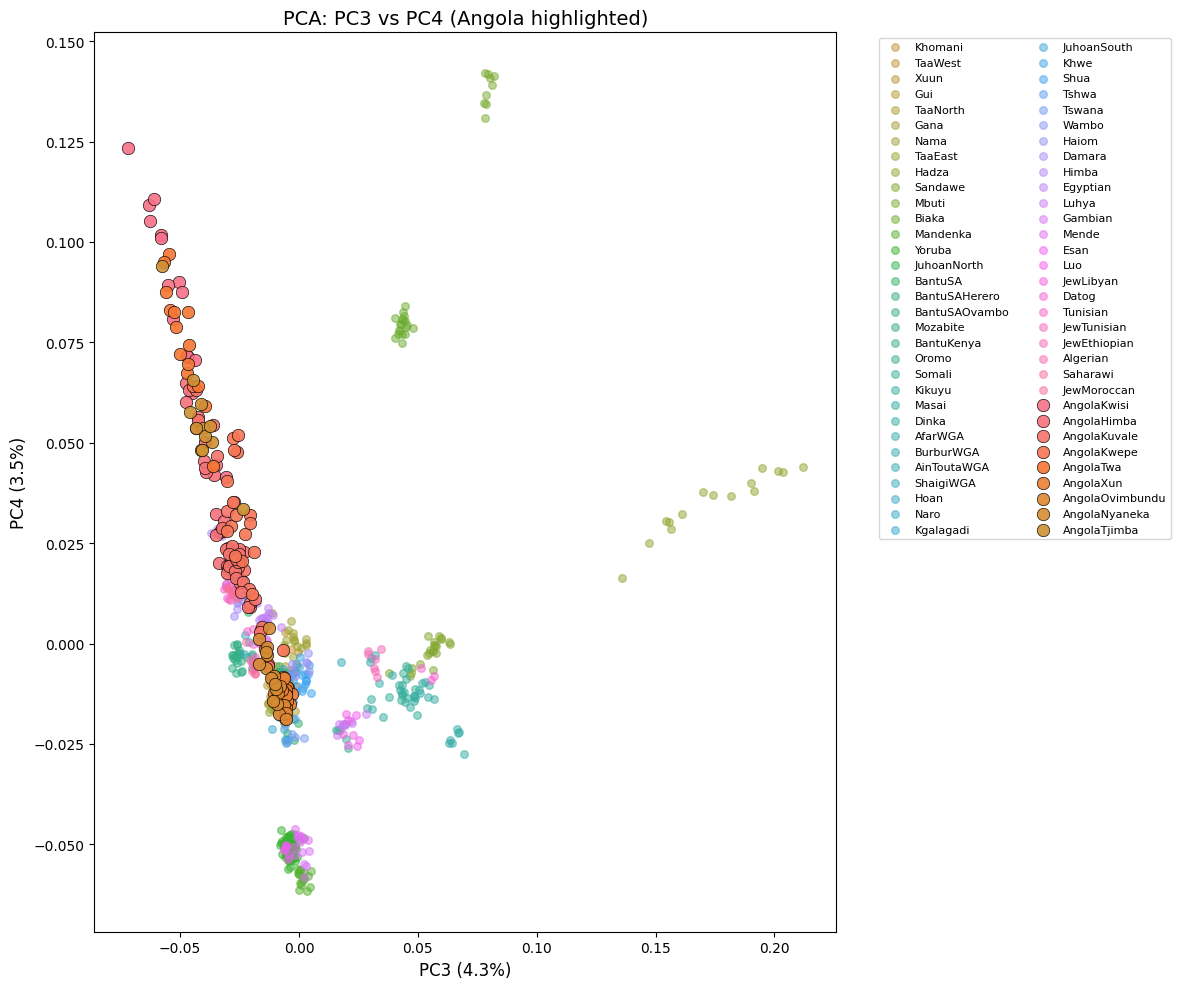

In [ ]:
# === ЭТАП 9: Отдельный график PC3 vs PC4 (крупный) ===
plt.figure(figsize=(12, 10))

for pop in populations:
    if not pop.startswith('Angola'):
        subset = pca_data[pca_data['Population'] == pop]
        plt.scatter(subset['PC3'], subset['PC4'],
                   label=pop, alpha=0.5, s=30, color=color_map[pop])

for pop in populations:
    if pop.startswith('Angola'):
        subset = pca_data[pca_data['Population'] == pop]
        plt.scatter(subset['PC3'], subset['PC4'],
                   label=pop, alpha=0.9, s=80,
                   color=color_map[pop], edgecolor='black', linewidth=0.5)

plt.xlabel(f'PC3 ({variance_explained[2]:.1f}%)', fontsize=12)
plt.ylabel(f'PC4 ({variance_explained[3]:.1f}%)', fontsize=12)
plt.title('PCA: PC3 vs PC4 (Angola highlighted)', fontsize=14)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8, ncol=2)
plt.tight_layout()
plt.savefig('pca_pc3_pc4.png', dpi=150, bbox_inches='tight')
plt.show()

# PC4 чётко отделяет ангольские популяции от остальных африканских групп.
# Это особенно заметно для AngolaXun (PC4 ≈ 0.12) — они выделяются даже
# среди других ангольских популяций.

# Итоговый вывод

Результат по PC4 менее надёжен, чем по PC1, потому что PC4 объясняет только 3.5% дисперсии против 38.2% у PC1 — это в 11 раз меньше. Слабый сигнал труднее отличить от шума, и результаты менее воспроизводимы при изменении параметров анализа.
Однако на нашем графике PC4 показывает биологически осмысленный паттерн: ангольские популяции выделяются, особенно AngolaXun — охотники-собиратели с койсанским языком. PC4 значимо коррелирует с долготой (p = 0.026), что подтверждает реальность эффекта.
Вывод: результат по PC4 — это предварительная гипотеза, требующая подтверждения, а не окончательное доказательство."